In [1]:
from utils.paths import *
from utils.constants import *
from utils.analysis import *
from utils.plotting import *
import numpy as np
import xarray as xr
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import itertools as it
from matplotlib import rcParams
from dateutil.relativedelta import relativedelta
import calendar
from matplotlib.cm import get_cmap


rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 10
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

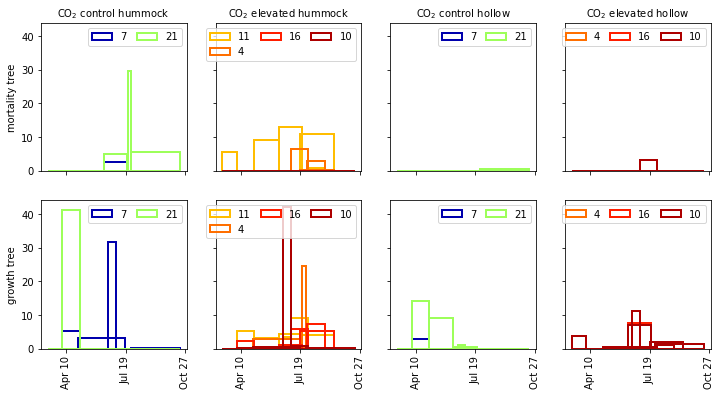

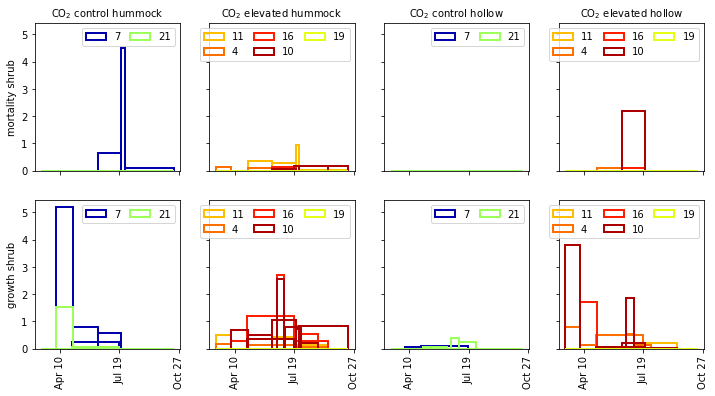

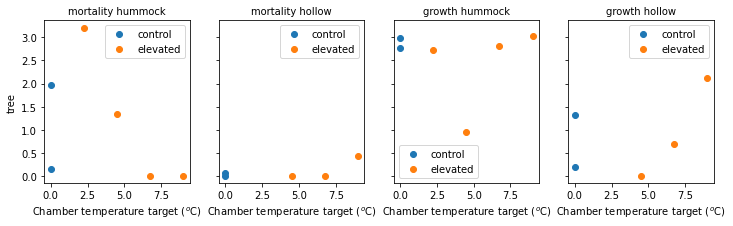

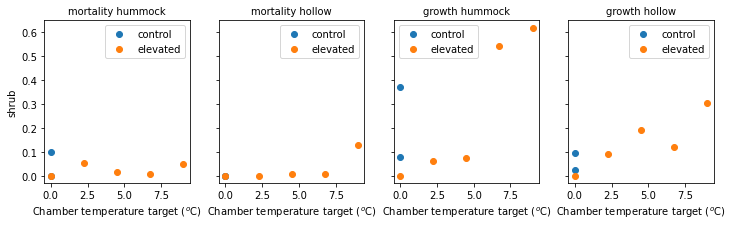

In [2]:
""" Examine Soren's root data
1. The seasonal cycle
2. Relationship between the average growth/mortality rate during the observation period and the temperature of the chamber
"""
minirhizotron = pd.read_csv(os.path.join(path_input, 'soren_root_prod_mort_growth_20230316.csv'))
minirhizotron['end_date'] = pd.DatetimeIndex(minirhizotron['end_date']) 
minirhizotron['start_date'] = pd.DatetimeIndex(minirhizotron['start_date'])

# Take the absolute value of mortality rate
minirhizotron['m_g_d'] = minirhizotron['m_g_d'].abs()

cmap = get_cmap('jet')
clist = dict(zip([7, 6, 20, 13, 8, 17, 21, 19, 11, 4, 16, 10], [cmap((i+0.5)/12) for i in range(12)]))


#########################################################################
# The seasonal cycle
#########################################################################
for pft in ['tree', 'shrub']:
    fig, axes = plt.subplots(2, 4, figsize = (12, 6), sharex = True, sharey = True)
    for a, var in enumerate(['m_g_d', 'g_g_d']):
        if var == 'm_g_d':
            varname = 'mortality'
        else:
            varname = 'growth'
        for i, loc in enumerate(['hummock', 'hollow']):
            for j, co2 in enumerate(['control', 'elevated']):
                ax = axes[a, i*2 + j]

                if a == 0:
                    ax.set_title(f'CO$_2$ {co2} {loc}')
                if (i + j) == 0:
                    ax.set_ylabel(f'{varname} {pft}')

                subset = minirhizotron.loc[(minirhizotron['pft'] == pft) & (minirhizotron['co2'] == co2) & (minirhizotron['topo'] == loc), :]
                chambers = subset[['plot', 'temp']].drop_duplicates().set_index('plot')['temp'].sort_values().index

                for k, cha in enumerate(chambers):
                    subset_temp = subset.loc[subset['plot'] == cha, ['start_date', 'end_date', var]]
                    widths = [t.days for t in (subset_temp['end_date'] - subset_temp['start_date'])]

                    # Overlay the individual years
                    mid = [(subset_temp['start_date'].iloc[i] + relativedelta(days = widths[i] // 2)).dayofyear for i in range(subset_temp.shape[0])]

                    ax.bar(x = mid, height = subset_temp[var], width = widths, align = 'center', label = cha, color = 'none', edgecolor = clist[cha], lw = 2)
                    ax.legend(ncol = 3, columnspacing = 1)

                    # Change the ticks into month-day
                    xticks = ax.get_xticks()
                    month_days = [datetime(2000, 1, 1) + timedelta(t) for t in xticks]
                    labels = [f'{calendar.month_abbr[md.month]} {md.day:02}' for md in month_days]
                    ax.set_xticklabels(labels)

                plt.setp(ax.get_xticklabels(), rotation = 90)


#########################################################################
# Relationship between the average growth/mortality rate during the
# observation period and the temperature of the chamber
#########################################################################
annual_growth = minirhizotron.copy()
annual_growth['days'] = np.array([t.days for t in (annual_growth['end_date'] - annual_growth['start_date'])])
annual_growth['m_g_mean'] = annual_growth['m_g_d'] * (annual_growth['days'] + 1)
annual_growth['g_g_mean'] = annual_growth['g_g_d'] * (annual_growth['days'] + 1)
annual_growth = annual_growth.drop(['start_date', 'end_date', 'time_step'], axis = 1 \
    ).groupby(['plot', 'topo', 'temp', 'co2', 'pft', 'year', 'tube']).sum()[['m_g_mean', 'g_g_mean', 'days']]
annual_growth['m_g_mean'] = annual_growth['m_g_mean'] / annual_growth['days']
annual_growth['g_g_mean'] = annual_growth['g_g_mean'] / annual_growth['days']
annual_growth = annual_growth.groupby(['pft', 'topo', 'co2', 'temp', 'plot']).mean()


clist = ['r', 'b']
for i, pft in enumerate(['tree', 'shrub']):
    fig, axes = plt.subplots(1, 4, figsize = (12, 3), sharex = True, sharey = True)
    for j, loc in enumerate(['hummock', 'hollow']):
        for k, var in enumerate(['m_g_mean', 'g_g_mean']):
            if var == 'm_g_mean':
                varname = 'mortality'
            else:
                varname = 'growth'
            ax = axes[k*2 + j]
            ax.set_title(f'{varname} {loc}')
            if (j + k) == 0:
                ax.set_ylabel(pft)
            for m, co2 in enumerate(['control', 'elevated']):        
                temp = annual_growth.loc[(pft, loc, co2), var].reset_index()

                temp.loc[temp['temp'].isin(['ambient', 'control']), 'temp'] = 0. # replace ambient with zero
                temp['temp'] = temp['temp'].astype(float)
                ax.plot(temp['temp'], temp[var], 'o', label = co2)
            ax.set_xlabel('Chamber temperature target ($^o$C)')
            ax.legend()

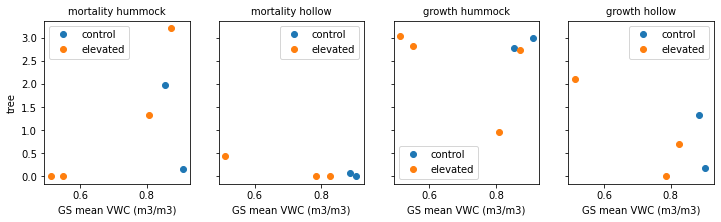

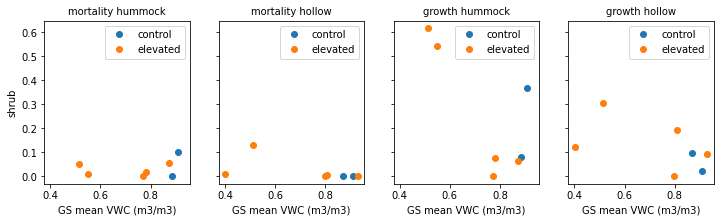

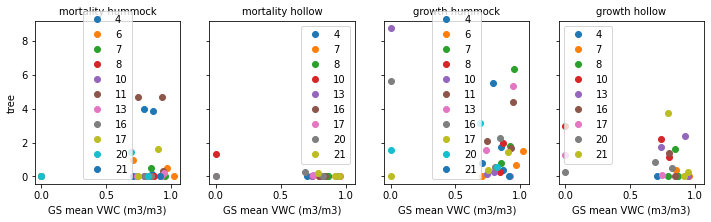

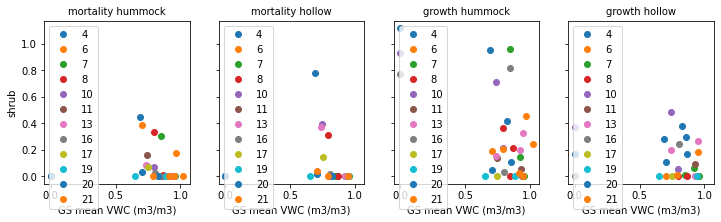

In [3]:
#########################################################################
# Check the relationship with volumetric soil moisture @ 20 cm, chamber
#########################################################################
hr = xr.open_dataset(os.path.join(path_intrim, 'spruce_validation_data.nc'))
swc = hr['halfhourly_swc'].resample({'time': '1D'}).mean().loc[:, :, 0.2]
swc = pd.DataFrame(swc.values, index = swc['time'].to_index(), columns = swc['chamber']).dropna(how = 'all', axis = 0)
swc = swc.loc[(swc.index.month >= 4) & (swc.index.month <= 10) & (swc.index.year >= 2018), :]
hr.close()

minirhizotron['swc'] = pd.Series(np.nan, index = minirhizotron.index)
for i in minirhizotron.index:
    minirhizotron.loc[i, 'swc'] = swc[minirhizotron.loc[i, 'plot']].loc[minirhizotron.loc[i, 'start_date']:minirhizotron.loc[i, 'end_date']].mean()


annual_growth = minirhizotron.copy()
annual_growth['days'] = np.array([t.days for t in (annual_growth['end_date'] - annual_growth['start_date'])])
annual_growth['m_g_mean'] = annual_growth['m_g_d'] * (annual_growth['days'] + 1)
annual_growth['g_g_mean'] = annual_growth['g_g_d'] * (annual_growth['days'] + 1)
annual_growth['swc'] = annual_growth['swc'] * (annual_growth['days'] + 1) # because there's a sum later
annual_growth = annual_growth.drop(['start_date', 'end_date', 'time_step'], axis = 1 \
    ).groupby(['plot', 'topo', 'temp', 'co2', 'pft', 'year', 'tube']).sum()[['m_g_mean', 'g_g_mean', 'swc', 'days']]
annual_growth['m_g_mean'] = annual_growth['m_g_mean'] / annual_growth['days']
annual_growth['g_g_mean'] = annual_growth['g_g_mean'] / annual_growth['days']
annual_growth['swc'] = annual_growth['swc'] / annual_growth['days']
annual_growth = annual_growth.groupby(['pft', 'topo', 'co2', 'temp', 'plot']).mean()


clist = ['r', 'b']
for i, pft in enumerate(['tree', 'shrub']):
    fig, axes = plt.subplots(1, 4, figsize = (12, 3), sharex = True, sharey = True)
    for j, loc in enumerate(['hummock', 'hollow']):
        for k, var in enumerate(['m_g_mean', 'g_g_mean']):
            if var == 'm_g_mean':
                varname = 'mortality'
            else:
                varname = 'growth'
            ax = axes[k*2 + j]
            ax.set_title(f'{varname} {loc}')
            if (j + k) == 0:
                ax.set_ylabel(pft)
            for m, co2 in enumerate(['control', 'elevated']):        
                temp = annual_growth.loc[(pft, loc, co2), :].reset_index()
                ax.plot(temp['swc'], temp[var], 'o', label = co2)
            ax.set_xlabel('GS mean VWC (m3/m3)')
            ax.legend()



#########################################################################
# Check the relationship with volumetric soil moisture @ 20 cm, annual
#########################################################################
annual_growth = minirhizotron.copy()
annual_growth['days'] = np.array([t.days for t in (annual_growth['end_date'] - annual_growth['start_date'])])
annual_growth['m_g_mean'] = annual_growth['m_g_d'] * (annual_growth['days'] + 1)
annual_growth['g_g_mean'] = annual_growth['g_g_d'] * (annual_growth['days'] + 1)
annual_growth['swc'] = annual_growth['swc'] * (annual_growth['days'] + 1) # because there's a sum later
annual_growth = annual_growth.drop(['start_date', 'end_date', 'time_step'], axis = 1 \
    ).groupby(['plot', 'topo', 'temp', 'co2', 'pft', 'year', 'tube']).sum()[['m_g_mean', 'g_g_mean', 'swc', 'days']]
annual_growth['m_g_mean'] = annual_growth['m_g_mean'] / annual_growth['days']
annual_growth['g_g_mean'] = annual_growth['g_g_mean'] / annual_growth['days']
annual_growth['swc'] = annual_growth['swc'] / annual_growth['days']
annual_growth = annual_growth.groupby(['pft', 'topo', 'plot', 'co2', 'year', 'temp']).mean()


clist = ['r', 'b']
for i, pft in enumerate(['tree', 'shrub']):
    fig, axes = plt.subplots(1, 4, figsize = (12, 3), sharex = True, sharey = True)
    for j, loc in enumerate(['hummock', 'hollow']):
        for k, var in enumerate(['m_g_mean', 'g_g_mean']):
            if var == 'm_g_mean':
                varname = 'mortality'
            else:
                varname = 'growth'
            ax = axes[k*2 + j]
            ax.set_title(f'{varname} {loc}')
            if (j + k) == 0:
                ax.set_ylabel(pft)
            temp = annual_growth.loc[(pft, loc), :]
            for plot in np.unique(temp.index.get_level_values('plot')):
                ax.plot(temp.loc[plot, 'swc'], temp.loc[plot, var], 'o', label = plot)
            ax.set_xlabel('GS mean VWC (m3/m3)')
            ax.legend()

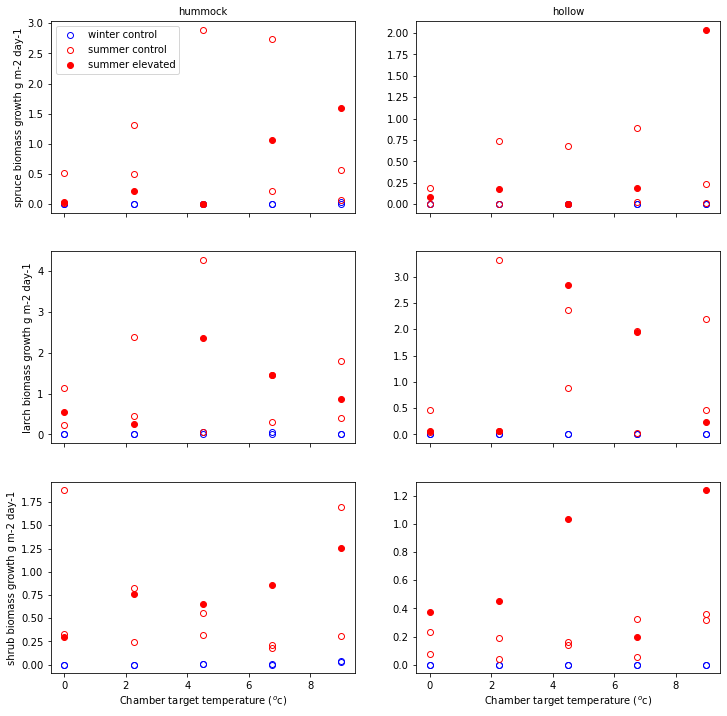

In [4]:
""" Examine the 2015-2017 ingrowth core data: annual biomass in the top 30 cm
Normaization is by area and length of core. The area of the core = the area of the chamber (assume uniform). 
There is very little root below 30cm. Therefore, assume this is equal to the whole soil column.  
"""
ingrowth = pd.read_csv(os.path.join(path_input, 'spruce_root_ingrowth_2014_2017_20200408.csv'), header = [0, 1], encoding = 'Windows-1252')
ingrowth.columns = [f'{i} {j}' if not 'Unnamed' in j else f'{i}' for i, j in zip(ingrowth.columns.get_level_values(0), ingrowth.columns.get_level_values(1))]
ingrowth['start_date yyyy-mm-dd'] = pd.DatetimeIndex(ingrowth['start_date yyyy-mm-dd'])
ingrowth['end_date yyyy-mm-dd'] = pd.DatetimeIndex(ingrowth['end_date yyyy-mm-dd'])
ingrowth['root_biomass g m-2 day-1'] = ingrowth['root_biomass g/m2/season'] / np.array([(d.days + 1) for d in (ingrowth['end_date yyyy-mm-dd'] - ingrowth['start_date yyyy-mm-dd'])])
season = np.array([d.split('_')[0].lower() for d in ingrowth['season']])


fig, axes = plt.subplots(3, 2, figsize = (12, 12), sharex = True, sharey = False)
for i, pft in enumerate(['spruce', 'larch', 'shrub']):
    for j, topo in enumerate(['hummock', 'hollow']):
        ax = axes[i, j]
        for k, (co2, co2name) in enumerate(zip([0, 500], ['control', 'elevated'])):
            for l, sea in enumerate(['winter', 'summer']):
                subset = ingrowth.loc[(ingrowth['pft'] == pft) & (ingrowth['topog hummock or hollow'] == topo) & (season == sea) & (ingrowth['co2_trmt ppm'] == co2), :]
                if subset.shape[0] != 0:
                    a = subset[['plot', 'temp_target degrees C']].groupby('plot').first().iloc[:, 0]
                    b = subset[['plot', 'root_biomass g m-2 day-1']].groupby('plot').sum().iloc[:, 0]

                    if sea == 'winter':
                        color = 'b'
                    else:
                        color = 'r'
                    if co2name == 'control':
                        fc = 'none'
                    else:
                        fc = color

                    ax.plot(a, b, 'o', color = color, markerfacecolor = fc, label = f'{sea} {co2name}')
        if (i == 0) & (j == 0):
            ax.legend()
        if j == 0:
            ax.set_ylabel(f'{pft} biomass growth g m-2 day-1')
        if i == 0:
            ax.set_title(topo)
        if i == 2:
            ax.set_xlabel('Chamber target temperature ($^o$c)')

In [5]:
""" Merge into postprocessing data format 
    Hollow and hummock have to be averaged
"""
header = ['Variable', 'Startyear', 'endyear', 'Startday', 'endday', 'averaging period',
          'factor', 'add offset', 'pft', 'obs', 'obs_err', 'treatment']
pft_stride = 17
chamber_list = [6, 19, 20, 11, 13, 4, 8, 16, 17, 10, 7]
chamber_list_names = dict(zip(chamber_list, ['T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2', 'TAMB']))

f = open(os.path.join('./temp/postproc_vars_SPRUCE_root'), 'w')
f.write('#' + '\t'.join(header) + '\n')


######################################################################
# seasonal minirhizotron observations
######################################################################
factor = 86400 * 2 # convert from gC m-2 s-1 to g biomass m-2 day-1
for elm_var, obs_var in zip(['FROOTC_ALLOC', 'FROOTC_TO_LITTER'], ['g_g_d', 'm_g_d']):
    for pft, pft_id in zip(['tree', 'shrub'], ['2,3', '11']):
        subset = minirhizotron.loc[minirhizotron['pft'] == pft, ['plot', 'topo', 'year', 'start_date', 'end_date', obs_var]]
        ind = subset[['plot', 'start_date', 'end_date']].drop_duplicates()

        # hummock-hollow averages
        aggregate = pd.DataFrame(np.nan, index = pd.MultiIndex.from_frame(ind), columns = [obs_var])
        for _, row in ind.iterrows():
            subset_subset = subset.loc[(subset['plot'] == row['plot']) & \
                                       (subset['start_date'] == row['start_date']) & \
                                       (subset['end_date'] == row['end_date']),
                                       ['topo', obs_var]].set_index('topo')[obs_var]
            # start_doy = pd.DatetimeIndex(subset_subset['start_date']).dayofyear
            # end_doy = pd.DatetimeIndex(subset_subset['end_date']).dayofyear
            if ('hollow' in subset_subset.index) and ('hummock' in subset_subset.index):
                aggregate.loc[tuple(row), :] = subset_subset.loc['hollow'] * 0.64 + subset_subset.loc['hummock'] * 0.36
        aggregate = aggregate.dropna().reset_index()
        aggregate['year'] = pd.DatetimeIndex(aggregate['start_date']).year
        aggregate['start_date'] = pd.DatetimeIndex(aggregate['start_date']).dayofyear
        aggregate['end_date'] = pd.DatetimeIndex(aggregate['end_date']).dayofyear

        for _, line in aggregate.iterrows():
            if not int(line.loc['plot']) in chamber_list:
                continue
            line = f'{elm_var}\t' + str(int(line.loc['year'])) + '\t' + str(int(line.loc['year'])) + '\t' + str(int(line.loc['start_date'])) + \
                   '\t' + str(int(line.loc['end_date'])) + '\t' + str(int(line.loc['end_date'] - line.loc['start_date'])) + '\t' + \
                   str(factor) + f'\t0\t{pft_id}\t' + str(line.loc[obs_var]) + '\t' + str(line.loc[obs_var]) + '\t' + chamber_list_names[int(line.loc['plot'])]
            f.write(line + '\n')


######################################################################
# annual ingrowth cores. Ignore the winter since it is not compatible with postproc and is almost zero. 
# Not sure yet if need to be Growth - Mortality, or just Growth
######################################################################
ingrowth2 = ingrowth.copy()
ingrowth2['root_biomass g m-2 day-1'] = ingrowth['root_biomass g/m2/season'] / (np.array([d.days for d in ingrowth['end_date yyyy-mm-dd'] - ingrowth['start_date yyyy-mm-dd']]) + 1)
ingrowth2 = ingrowth2.groupby(['topog hummock or hollow', 'start_date yyyy-mm-dd', 'end_date yyyy-mm-dd', 'plot', 'pft']).sum()[['root_biomass g m-2 day-1']]
# hummock-hollow averages
ingrowth2 = (ingrowth2.loc['hollow', :] * 0.64 + ingrowth2.loc['hummock', :] * 0.36).dropna(axis = 0)
ingrowth2 = ingrowth2.loc[ingrowth2.index.get_level_values('pft') != 'graminoid', :].reset_index()

factor = 86400 * 2 # convert from gC m-2 s-1 to g biomass m-2 day-1
elm_var = 'FROOTC_ALLOC-FROOTC_TO_LITTER' # !!!!!!!!!!!! NEED TO FIX

for _, row in ingrowth2.iterrows():
    year = row['start_date yyyy-mm-dd'].year

    line = f'{elm_var}\t{year}\t{year}\t' + str(row.loc['start_date yyyy-mm-dd'].dayofyear) + '\t' + \
           str(row.loc['end_date yyyy-mm-dd'].dayofyear) + '\t' + \
           str(row.loc['end_date yyyy-mm-dd'].dayofyear - row.loc['start_date yyyy-mm-dd'].dayofyear + 1) + \
           '\t' + str(factor) + f'\t0\t{pft_id}\t' + str(row.loc['root_biomass g m-2 day-1']) + '\t' + \
           str(row.loc['root_biomass g m-2 day-1']) + '\t' + chamber_list_names[int(row.loc['plot'])]
    f.write(line + '\n')

f.close()

In [6]:
"""
Give set of parameters
* Calculate fine root growth and death rates using default ELM outputs 
* Use `postproc` to compare the calculated values to observations
* Save the metrics to .csv file
"""
params = dict(
    td_base = 10,
    td_scale = 0.00175 / 4, 
    td_offset = 0.1, 
    td_max = 0.5, 
    wd_scale = 0.05, 
    wd_base = 35, 
    wd_thres = 0.6, 
    f_stor = 1/180,
    downreg_a = 1,
    zwt_max = 10,
    zwt_a = 1, 
    zwt_min = 0.1, 
    froot_long = 2, 
    fcur = 0.5
)


def calculator(tvec, dt, leaf_onset, tsoi, swc, psoi, cpool_to_froot, frootc_storage, downreg, zwt, sucsat, watsat, bsw, params):
    """ tvec is DatetimeIndex
        dt is the size of the time step (in seconds)
        The drivers are 1-D numpy arrays indexed by tvec in the first dimension
    """
    # calculate the soil matric potential at wd_thres
    psi_crit = - sucsat * np.power(np.maximum(params['wd_thres'] / watsat, 0.01), -bsw)

    td = np.minimum(params['td_max'], params['td_scale'] * np.power(tsoi - params['td_base'], 2))

    wd_le_base = 0.5 + 1 / np.pi * np.arctan(params['wd_scale'] * np.pi * (np.abs(psoi) - params['wd_base']))
    wd_at_base = 0.5 + 1 / np.pi * np.arctan(params['wd_scale'] * np.pi * (np.abs(psi_crit) - params['wd_base']))
    wd_ge_base = (swc - params['wd_thres']) / (1 - params['wd_thres']) * (1 - wd_at_base) + wd_at_base
    wd = np.where(swc >= params['wd_thres'], wd_ge_base, wd_le_base)

    # mortality rate
    mortality = 1 / (params['froot_long'] * 365 * 86400) * 2 * np.maximum(td, wd)

    # compensatory growth rate
    td_0 = np.minimum(params['td_max'], params['td_scale'] * np.power(params['td_base'], 2))
    m0 = 1 / (params['froot_long'] * 365 * 86400) * 2 * td_0
    growth_compens = np.minimum(np.where(tsoi < 0, np.maximum(mortality - m0, 0), 0), frootc_storage / dt)


    fnmin = 1 + np.power(downreg, params['downreg_a'])
    fw = np.minimum(1, np.maximum(1 - np.power(zwt, params['zwt_a']) / params['zwt_max'], params['zwt_min']))

    # get the carbon storage on the first day of leaf onset
    frootc_storage_day0 = np.zeros(len(frootc_storage))
    year_list = np.unique(tvec.year)
    for yy in year_list:
        day0 = np.where((tvec.year == yy) & (leaf_onset > 0))[0][0]
        frootc_storage_day0[tvec.year == yy] = frootc_storage[day0]

    # transfer growth rate
    growth_onset = params['f_stor'] / 86400 * frootc_storage_day0 * fnmin * fw + params['fcur'] * cpool_to_froot
    growth_onset = np.where(tsoi > 0, growth_onset, 0)

    # flag: between winter solstice and date of onset, or not
    fleaf = np.empty(len(frootc_storage))
    for yy in year_list:
        day0 = np.where((tvec.year == yy) & (leaf_onset > 0))[0][0]
        day_sol = np.where((tvec.year == yy) & ((tvec.month * 100 + tvec.day) >= 1221))[0][0]
        fleaf_thisyear = np.zeros(sum(tvec.year == yy))
        fleaf_thisyear[day0:day_sol] = 0
        fleaf[tvec.year == yy] = fleaf_thisyear
    
    growth = np.where(fleaf > 0, growth_onset, growth_compens)

    return growth, mortality


def extractor(casename):
    tvec = pd.date_range('2015-01-01', '2020-12-31', freq = '1D')
    tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
    pft_list = [2, 3, 11]
    dt = 3600 # hourly

    growth = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))
    mortality = pd.DataFrame(np.nan, index = tvec, columns = pd.MultiIndex.from_product([['2','3','11'], ['hummock', 'hollow']]))

    path_files = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run')
    flist = sorted(glob(path_files + '/*.h2.nc'))[:-1]
    hr = xr.open_mfdataset(flist)

    for pft, loc in it.product(pft_list, ['hummock','hollow']):
        if loc == 'hummock':
            pft_id = pft
        else:
            pft_id = pft + 17

        leaf_onset = (hr['AGNPP'][:, pft_id] > 0)
        tsoi = 

    hr.close()

'\nGive set of parameters\n* Calculate fine root growth and death rates using default ELM outputs \n* Use `postproc` to compare the calculated values to observations\n* Save the metrics to .csv file\n'

In [8]:
""" Use Taylor diagram & Pareto front to compare the parameters effects """
os.environ['PROJDIR']

'/lustre/or-scratch/cades-ccsi/scratch/ywo'